In [1]:
import pandas as pd
import numpy as np

def dcg_at_k(relevance_scores, k=10):
    relevance_scores = np.array(relevance_scores)[:k]
    return np.sum(relevance_scores / np.log2(np.arange(2, len(relevance_scores) + 2)))

def ndcg_at_k(predicted_order, gold_order, k=10, binary_relevance=False):

    if binary_relevance:
        gold_set = set(gold_order)
        predicted_relevance = [1 if item in gold_set else 0 for item in predicted_order]
        ideal_relevance = [1] * len(gold_order)  
    else:
        relevance_map = {item: len(gold_order) - i for i, item in enumerate(gold_order)}
        predicted_relevance = [relevance_map.get(item, 0) for item in predicted_order]
        ideal_relevance = [relevance_map[item] for item in gold_order]
    
    dcg = dcg_at_k(predicted_relevance, k)
    idcg = dcg_at_k(ideal_relevance, k)
    
    if idcg == 0:
        return 0.0
    
    return dcg / idcg


In [5]:
import ast
import collections as c

def safe_literal_eval(x):
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except Exception:
            return None
    return x

file_path = 'output/full_results.csv'
df_results = pd.read_csv(file_path)
df_results['recommendation'] = df_results['recommendation'].apply(safe_literal_eval)

strategies_list = ["ADD", "APP", "LMS", "MPL", "MAJ", "BORDA", 'AWM']

for strategy in strategies_list:
    df_results[strategy] = df_results[strategy].apply(safe_literal_eval)
    
    ndcg_col = f"{strategy}_ndcg10"
    df_results[ndcg_col] = df_results.apply(
        lambda row: ndcg_at_k(row["recommendation"], row[strategy], k=10, binary_relevance=True),
        axis=1
    )
df_results = df_results.head(7200)
print(len(df_results), c.Counter(df_results['configuration']))
#df_results.to_csv(file_path, index=False)

7200 Counter({'divergent': 1800, 'uniform': 1800, 'coalitional': 1800, 'minority': 1800})


In [6]:
df_results[['configuration', 'domain', 'num_items','llm','ADD_ndcg10', 'APP_ndcg10', 'LMS_ndcg10', 'MPL_ndcg10', 'MAJ_ndcg10', 'BORDA_ndcg10', 'AWM_ndcg10']].groupby(['llm','configuration', 'domain', 'num_items']).mean().to_excel('res.xlsx')
display(df_results[['configuration', 'domain', 'num_items','llm','ADD_ndcg10', 'APP_ndcg10', 'LMS_ndcg10', 'MPL_ndcg10', 'MAJ_ndcg10', 'BORDA_ndcg10', 'AWM_ndcg10']].groupby(['llm','configuration', 'domain', 'num_items']).mean())

ADD_ndcg10  \
llm                        configuration domain  num_items               
gpt-oss:120b-cloud         coalitional   anon    25           0.993638   
                                                 50           0.983353   
                                                 75           0.966786   
                                         movies  25           0.996183   
                                                 50           0.965189   
...                                                                ...   
mistral-large-3:675b-cloud uniform       movies  50           0.850841   
                                                 75           0.813395   
                                         tourist 25           0.897779   
                                                 50           0.810294   
                                                 75           0.752808   

                                                            APP_ndcg10  \
llm                        configuration domain  num_items               
gpt-oss:120b-cloud         coalitional   anon    25           0.828956   
                                                 50           0.710889   
                                                 75           0.703026   
                                         movies  25           0.812150   
                                                 50           0.685712   
...                                                                ...   
mistral-large-3:675b-cloud uniform       movies  50           0.755921   
                                                 75           0.671584   
                                         tourist 25           0.821563   
                                                 50           0.711520   
                                                 75           0.639380   

                                                            LMS_ndcg10  \
llm                        configuration domain  num_items               
gpt-oss:120b-cloud         coalitional   anon    25           0.731034   
                                                 50           0.711437   
                                                 75           0.686788   
                                         movies  25           0.733213   
                                                 50           0.697053   
...                                                                ...   
mistral-large-3:675b-cloud uniform       movies  50           0.704234   
                                                 75           0.678661   
                                         tourist 25           0.803258   
                                                 50           0.653083   
                                                 75           0.647606   

                                                            MPL_ndcg10  \
llm                        configuration domain  num_items               
gpt-oss:120b-cloud         coalitional   anon    25           0.691253   
                                                 50           0.415056   
                                                 75           0.342882   
                                         movies  25           0.692030   
                                                 50           0.420001   
...                                                                ...   
mistral-large-3:675b-cloud uniform       movies  50           0.593180   
                                                 75           0.480619   
                                         tourist 25           0.786836   
                                                 50           0.619111   
                                                 75           0.526920   

                                                            MAJ_ndcg10  \
llm                        configuration domain  num_items               
gpt-oss:120b-cloud         coalitional   anon    25         

In [ ]:
display(df_results[['llm','ADD_ndcg10', 'APP_ndcg10', 'LMS_ndcg10', 'MPL_ndcg10', 'MAJ_ndcg10', 'BORDA_ndcg10', 'AWM_ndcg10']].groupby(['llm']).mean())

,ADD_ndcg10,APP_ndcg10,LMS_ndcg10,MPL_ndcg10,MAJ_ndcg10,BORDA_ndcg10,AWM_ndcg10
llm,,,,,,,
gpt-oss:120b-cloud,0.980064,0.762387,0.707849,0.523889,0.380108,0.931848,0.926892
gpt-oss:20b-cloud,0.942912,0.748823,0.694370,0.518593,0.377109,0.907198,0.895849
ministral-3:8b-cloud,0.630315,0.549643,0.482884,0.538047,0.407090,0.625993,0.609322
mistral-large-3:675b-cloud,0.801932,0.667804,0.616586,0.556240,0.411320,0.792084,0.774886


In [120]:
df_results[
    ['ADD_ndcg10', 'APP_ndcg10', 'LMS_ndcg10',
     'MPL_ndcg10', 'MAJ_ndcg10', 'BORDA_ndcg10', 'AWM_ndcg10']
].mean()


ADD_ndcg10      0.838806
APP_ndcg10      0.682164
LMS_ndcg10      0.625422
MPL_ndcg10      0.534192
MAJ_ndcg10      0.393907
BORDA_ndcg10    0.814280
AWM_ndcg10      0.801737
dtype: float64

In [132]:
display(df_results[['domain', 'ADD_ndcg10', 'APP_ndcg10', 'LMS_ndcg10', 'MPL_ndcg10', 'MAJ_ndcg10', 'BORDA_ndcg10', 'AWM_ndcg10']].groupby(['domain']).mean())

,ADD_ndcg10,APP_ndcg10,LMS_ndcg10,MPL_ndcg10,MAJ_ndcg10,BORDA_ndcg10,AWM_ndcg10
domain,,,,,,,
anon,0.865934,0.700529,0.634704,0.554114,0.403739,0.839672,0.824802
movies,0.837505,0.681156,0.628651,0.528149,0.386716,0.814226,0.803593
tourist,0.812977,0.664807,0.612912,0.520314,0.391266,0.788944,0.776817


In [135]:
display(df_results[['configuration','ADD_ndcg10', 'APP_ndcg10', 'LMS_ndcg10', 'MPL_ndcg10', 'MAJ_ndcg10', 'BORDA_ndcg10', 'AWM_ndcg10']].groupby(['configuration']).mean())

,ADD_ndcg10,APP_ndcg10,LMS_ndcg10,MPL_ndcg10,MAJ_ndcg10,BORDA_ndcg10,AWM_ndcg10
configuration,,,,,,,
coalitional,0.825812,0.659137,0.614517,0.506631,0.371880,0.797694,0.788385
divergent,0.807633,0.628720,0.526140,0.483520,0.381032,0.781006,0.744374
minority,0.849003,0.694183,0.637130,0.530631,0.399231,0.823843,0.813580
uniform,0.872774,0.746618,0.723903,0.615987,0.423486,0.854579,0.860609


In [36]:
display(df_results[['num_items','llm','ADD_ndcg10', 'APP_ndcg10', 'LMS_ndcg10', 'MPL_ndcg10', 'MAJ_ndcg10', 'BORDA_ndcg10', 'AWM_ndcg10']].groupby(['llm','num_items']).mean())

ADD_ndcg10  APP_ndcg10  LMS_ndcg10  \
llm                        num_items                                       
gpt-oss:120b-cloud         25           0.995095    0.834396    0.742827   
                           50           0.982664    0.746033    0.694621   
                           75           0.962433    0.706733    0.686099   
gpt-oss:20b-cloud          25           0.977423    0.828400    0.733493   
                           50           0.947980    0.734228    0.686103   
                           75           0.903333    0.683842    0.663515   
ministral-3:8b-cloud       25           0.772961    0.714245    0.642076   
                           50           0.600239    0.514770    0.440215   
                           75           0.517744    0.419915    0.366362   
mistral-large-3:675b-cloud 25           0.884766    0.794675    0.716119   
                           50           0.788865    0.642090    0.588682   
                           75           0.732164    0.566646    0.544958   

                                      MPL_ndcg10  MAJ_ndcg10  BORDA_ndcg10  \
llm                        num_items                                         
gpt-oss:120b-cloud         25           0.718386    0.527471      0.945074   
                           50           0.478070    0.342210      0.933831   
                           75           0.375212    0.270644      0.916638   
gpt-oss:20b-cloud          25           0.713420    0.523152      0.935451   
                           50           0.475895    0.339907      0.911101   
                           75           0.366462    0.268269      0.875041   
ministral-3:8b-cloud       25           0.671436    0.528535      0.765807   
                           50           0.513374    0.375936      0.598654   
                           75           0.429332    0.316799      0.513517   
mistral-large-3:675b-cloud 25           0.719219    0.538025      0.869366   
                           50           0.513946    0.372880      0.777610   
                           75           0.435554    0.323057      0.729276   

                                      AWM_ndcg10  
llm                        num_items              
gpt-oss:120b-cloud         25           0.878573  
                           50           0.955815  
                           75           0.946287  
gpt-oss:20b-cloud          25           0.868838  
                           50           0.926499  
                           75           0.892209  
ministral-3:8b-cloud       25           0.729033  
                           50           0.590654  
                           75           0.508280  
mistral-large-3:675b-cloud 25           0.822101  
                           50           0.778369  
                           75           0.724188

In [ ]:
e_m = df_results


In [15]:
e_m_exploded = e_m.assign(label=e_m['labels'].str.split(', ')).explode('label')
scenario_totals = (e_m.groupby(['llm', 'configuration', 'num_items', 'domain']).size().rename('total'))
e_m_exploded = e_m_exploded.merge(scenario_totals,on=['llm', 'configuration', 'num_items', 'domain'],how='left')
label_counts = (
    e_m_exploded
    .groupby(['llm', 'configuration', 'num_items', 'domain', 'label'])
    .size()
    .reset_index(name='count')
)
label_counts = label_counts.merge(
    scenario_totals.reset_index(),
    on=['llm', 'configuration', 'num_items', 'domain'],
    how='left'
)

label_counts['percentage'] = label_counts['count'] / label_counts['total']
label_percentages_pivot = label_counts.pivot_table(
    index=['label', 'num_items', 'configuration', 'domain'],
    columns='llm',
    values='percentage',
    fill_value=0
)
label_percentages_pivot.to_csv('expl_percent.csv')
e_m.to_csv('full_results.csv')

In [121]:
label_counts[['label', 'percentage']].groupby(['label']).mean()

,percentage
label,
ADD,0.033200
APP,0.125161
AWM,0.326582
Ave,0.806944
BAL,0.079701
Div,0.177358
FAI,0.383256
LMS,0.026667
MPL,0.030732


In [16]:
label_counts[['llm',  'label', 'domain','percentage']].groupby(['llm', 'domain','label']).mean()

percentage
llm                        domain  label            
gpt-oss:120b-cloud         anon    ADD         0.060
                                   AWM         0.030
                                   Ave         0.945
                                   FAI         0.025
                                   MPL         0.020
...                                              ...
mistral-large-3:675b-cloud tourist Div         0.025
                                   FAI         0.610
                                   MPL         0.030
                                   Other       0.020
                                   Pop         0.020

[90 rows x 1 columns]

In [134]:
label_counts[label_counts['llm'] == 'mistral-large-3:675b-cloud'] \
    [['llm', 'label', 'domain', 'percentage']] \
    .groupby(['llm', 'domain', 'label']) \
    .mean()

percentage
llm                        domain  label            
mistral-large-3:675b-cloud anon    ADD      0.026667
                                   APP      0.022857
                                   AWM      0.661667
                                   Ave      0.338333
                                   BAL      0.133333
                                   Div      0.036364
                                   FAI      0.811667
                                   LMS      0.030000
                                   Sim      0.025000
                           movies  ADD      0.020000
                                   APP      0.038182
                                   AWM      0.653333
                                   Ave      0.343333
                                   BAL      0.024444
                                   Div      0.020000
                                   FAI      0.640000
                                   MPL      0.025000
                                   Other    0.020000
                                   Pop      0.020000
                                   Sim      0.040000
                           tourist ADD      0.020000
                                   APP      0.037143
                                   AWM      0.600000
                                   Ave      0.398333
                                   BAL      0.067273
                                   Div      0.025000
                                   FAI      0.610000
                                   MPL      0.030000
                                   Other    0.020000
                                   Pop      0.020000

In [17]:
label_counts[['llm',  'label', 'percentage']].groupby(['llm','label']).mean()

percentage
llm                        label            
gpt-oss:120b-cloud         ADD      0.040000
                           AWM      0.026667
                           Ave      0.973333
                           FAI      0.023636
                           MPL      0.020000
gpt-oss:20b-cloud          ADD      0.030526
                           APP      0.020000
                           AWM      0.020000
                           Ave      0.968333
                           BAL      0.020000
                           Div      0.020000
                           FAI      0.033333
                           LMS      0.020000
                           MPL      0.022500
                           Other    0.029333
ministral-3:8b-cloud       APP      0.191667
                           AWM      0.077059
                           Ave      0.926111
                           BAL      0.081176
                           Div      0.246111
                           FAI      0.218333
                           MPL      0.036364
                           Pop      0.020000
                           Sim      0.034000
mistral-large-3:675b-cloud ADD      0.022222
                           APP      0.033600
                           AWM      0.638333
                           Ave      0.360000
                           BAL      0.080000
                           Div      0.032500
                           FAI      0.687222
                           LMS      0.030000
                           MPL      0.027500
                           Other    0.020000
                           Pop      0.020000
                           Sim      0.028000

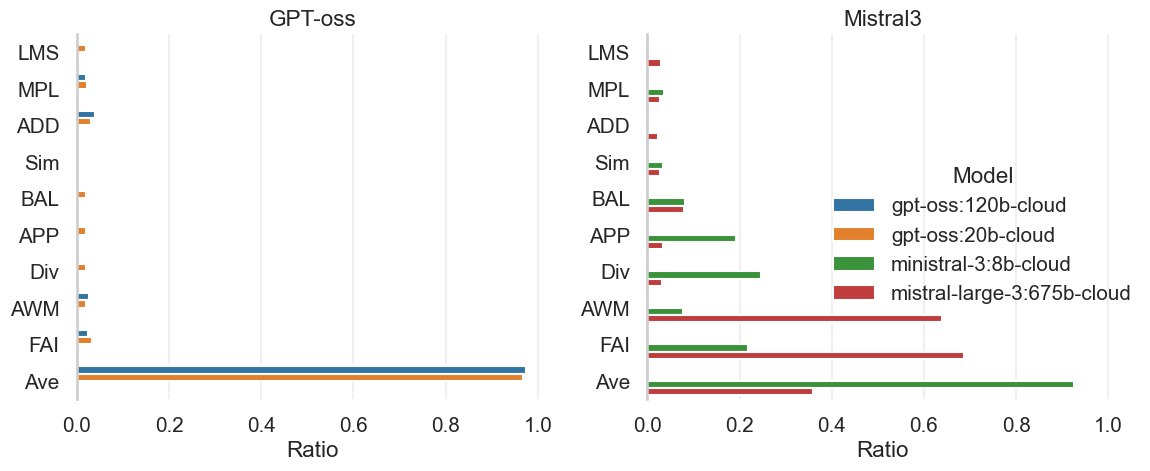

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

def model_family(llm: str) -> str:
    llm = llm.lower()
    if "gpt" in llm in llm:
        return "GPT-oss"
    elif "stral" in llm in llm:
        return "Mistral3"
    else:
        return "Other"

df = (
    label_counts[['llm', 'label', 'percentage']]
    .groupby(['llm', 'label'], as_index=False)
    .mean()
)

df["family"] = df["llm"].apply(model_family)

label_max = df.groupby("label")["percentage"].max()
keep_labels = label_max[label_max >= 0.03].index

df = df[df["label"].isin(keep_labels)]
label_order = (
    df.groupby("label")["percentage"]
    .mean()
    .sort_values()
    .index
)

sns.set_theme(
    style="whitegrid",
    context="talk",
    font_scale=0.9
)

g = sns.catplot(
    data=df,
    kind="bar",
    x="percentage",
    y="label",
    hue="llm",         
    col="family",      
    order=label_order,
    height=5,
    aspect=0.85,
    palette="tab10",
    dodge=True,
    errorbar=None,
    sharey=False        
)
for ax in g.axes.flat:
    ax.grid(axis="x", alpha=0.3)
    ax.set_xlim(left=0)
    sns.despine(ax=ax, left=False, bottom=True)

g.set_axis_labels("Ratio", "")
g.set_titles("{col_name}")
g._legend.set_title("Model")
plt.tight_layout()
plt.show()



In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from itertools import product

def model_family(llm: str) -> str:
    llm = llm.lower()
    if "gpt" in llm:
        return "GPT"
    elif "stral" in llm:
        return "Mistral3"
    else:
        return "Other"


label_name_map = {
    "Ave": "Averaging",
    "FAI": "Fairness",
    "AWM": "Ave w/o Misery",
    "Div": "Diversity",
    "APP": "APP",
    "Div": "Diversity",
    "BAL": "Balancing",
    "Sim": "Similarity",
    }

model_name_map = {
    "gpt-oss:120b-cloud": "GPT-oss-120b",
    "gpt-oss:20b-cloud": "GPT-oss-20b",
    "ministral-3:8b-cloud": "Ministral3-8b",
    "mistral-large-3:675b-cloud": "Mistral3-675b",
    }


domain_name_map = {
    "anon": 'Anonymous',
    "movies": 'Movies',
    'tourist': 'Tourism'
}
df = (
    label_counts[['llm', 'label', 'percentage', 'domain']]
    .groupby(['llm', 'label', 'domain'], as_index=False)
    .mean()
)

df["family"] = df["llm"].apply(model_family)

label_max = df.groupby("label")["percentage"].max()
keep_labels = label_max[label_max >= 0.05].index
df = df[df["label"].isin(keep_labels)]

all_families = df['family'].unique()
all_labels = keep_labels
all_domains = df['domain'].unique()

family_llm_map = df.groupby('family')['llm'].unique().to_dict()

complete_dfs = []
for family in all_families:
    family_llms = family_llm_map[family]
    complete_dfs.append(pd.DataFrame(
        list(product([family], family_llms, all_labels, all_domains)),
        columns=['family', 'llm', 'label', 'domain']
    ))

complete_index = pd.concat(complete_dfs, ignore_index=True)

df = complete_index.merge(
    df,
    on=['family', 'llm', 'label', 'domain'],
    how='left'
)
df['percentage'] = df['percentage'].fillna(0)


df["label_full"] = df["label"].map(label_name_map).fillna(df["label"])
df["llm_ren"] = df["llm"].map(model_name_map).fillna(df["llm"])
df["domain_ren"] = df["domain"].map(domain_name_map).fillna(df["domain"])

label_order = (
    df[df['percentage'] > 0]
    .groupby("label_full")["percentage"]
    .mean()
    .sort_values()
    .index
)


colors = ['#2E86AB', "#A01313", "#126F1B", "#A953EA", '#6A994E', '#BC4B51']
patterns = ['', '///', '...', 'xxx', '\\\\\\', '|||']

sns.set_theme(
    style="whitegrid",
    context="talk",
    font_scale=0.85
)


g = sns.catplot(
    data=df,
    kind="bar",
    x="label_full",
    y="percentage",
    hue="llm_ren",
    col="family",
    #row="family",
    order=label_order,
    height=4,
    aspect=1,
    palette=colors,
    dodge=True,
    errorbar=None,
    sharey=True,sharex=False   
)


for ax in g.axes.flat:
    for i, container in enumerate(ax.containers):
        for bar in container:
            bar.set_hatch(patterns[i % len(patterns)])
            bar.set_edgecolor('white')
            bar.set_linewidth(0.01)

    ax.grid(axis="y", alpha=0.25, linestyle='-', linewidth=0.8)
    ax.set_axisbelow(True)
    ax.set_ylim(bottom=0)
    ax.set_facecolor('#FAFAFA')
    sns.despine(ax=ax, left=True, bottom=True)

    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda y, _: f"{int(y * 100)}%")
    )

    ax.tick_params(axis='x', labelbottom=True)

    ax.tick_params(axis='y', labelsize=12)
    ax.tick_params(axis='x', labelsize=14, length=0)

    plt.setp(
        ax.get_xticklabels(),
        rotation=35,
        ha="right",
        visible=True
    )



g.set_titles(
    col_template="{col_name}",
    row_template="{row_name}",
    size=16,
    weight='bold',
    pad=10
)

g.set_axis_labels("",
    "Percentage",
    fontsize=14
)


handles, labels = g.axes.flat[0].get_legend_handles_labels()

new_handles = []
for i, label in enumerate(labels):
    new_handles.append(
        mpatches.Patch(
            facecolor=colors[i % len(colors)],
            edgecolor='white',
            hatch=patterns[i % len(patterns)],
            linewidth=1.2,
            label=label
        )
    )

g._legend.remove()
g.fig.legend(
    handles=new_handles,
    labels=labels,
    title="Model",
    loc='center right',
    bbox_to_anchor=(0.02, 0.5),
    frameon=True,
    fancybox=True,
    shadow=True,
    title_fontsize=10,
    fontsize=12
)


plt.tight_layout()
plt.subplots_adjust(right=0.88)
plt.savefig('model-expl.png', dpi=750, bbox_inches='tight')
plt.show()


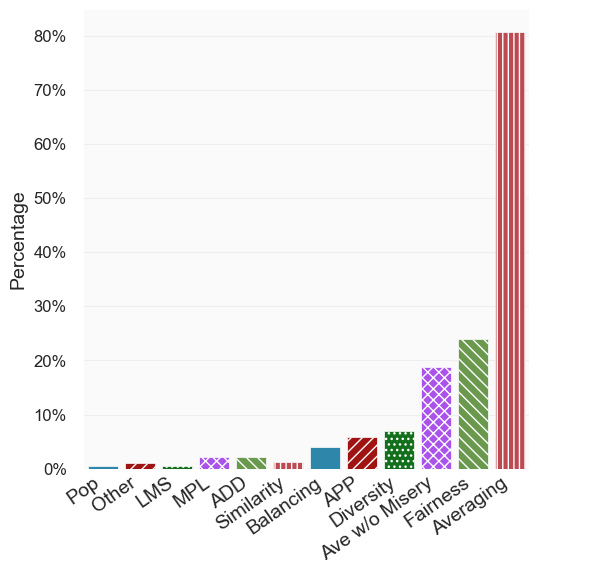

In [86]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from itertools import product

def model_family(llm: str) -> str:
    llm = llm.lower()
    if "gpt" in llm:
        return "GPT"
    elif "stral" in llm:
        return "Mistral3"
    else:
        return "Other"


label_name_map = {
    "Ave": "Averaging",
    "FAI": "Fairness",
    "AWM": "Ave w/o Misery",
    "Div": "Diversity",
    "APP": "APP",
    "Div": "Diversity",
    "BAL": "Balancing",
    "Sim": "Similarity",
    }

model_name_map = {
    "gpt-oss:120b-cloud": "GPT-oss-120b",
    "gpt-oss:20b-cloud": "GPT-oss-20b",
    "ministral-3:8b-cloud": "Ministral3-8b",
    "mistral-large-3:675b-cloud": "Mistral3-675b",
    }


domain_name_map = {
    "anon": 'Anonymous',
    "movies": 'Movies',
    'tourist': 'Tourism'
}
df = (
    label_counts[['llm', 'label', 'percentage', 'domain']]
    .groupby(['llm', 'label', 'domain'], as_index=False)
    .mean()
)

df["family"] = df["llm"].apply(model_family)

label_max = df.groupby("label")["percentage"].max()
keep_labels = label_max[label_max >= 0.01].index
df = df[df["label"].isin(keep_labels)]

all_families = df['family'].unique()
all_labels = keep_labels
all_domains = df['domain'].unique()

family_llm_map = df.groupby('family')['llm'].unique().to_dict()

complete_dfs = []
for family in all_families:
    family_llms = family_llm_map[family]
    complete_dfs.append(pd.DataFrame(
        list(product([family], family_llms, all_labels, all_domains)),
        columns=['family', 'llm', 'label', 'domain']
    ))

complete_index = pd.concat(complete_dfs, ignore_index=True)

df = complete_index.merge(
    df,
    on=['family', 'llm', 'label', 'domain'],
    how='left'
)
df['percentage'] = df['percentage'].fillna(0)


df["label_full"] = df["label"].map(label_name_map).fillna(df["label"])
df["llm_ren"] = df["llm"].map(model_name_map).fillna(df["llm"])
df["domain_ren"] = df["domain"].map(domain_name_map).fillna(df["domain"])

label_order = (
    df[df['percentage'] > 0]
    .groupby("label_full")["percentage"]
    .mean()
    .sort_values()
    .index
)


colors = ['#2E86AB', "#A01313", "#126F1B", "#A953EA", '#6A994E', '#BC4B51']
patterns = ['', '///', '...', 'xxx', '\\\\\\', '|||']

sns.set_theme(
    style="whitegrid",
    context="talk",
    font_scale=0.85
)


g = sns.catplot(
    data=df,
    kind="bar",
    x="label_full",
    y="percentage",
    #hue="label_full",
    #col="family",
    #row="family",
    order=label_order,
    height=6,
    #aspect=1,
    #palette=colors,
    dodge=True,
    errorbar=None,
    sharey=True,sharex=False   
)


for ax in g.axes.flat:
    for i, bar in enumerate(ax.patches):
        bar.set_facecolor(colors[i % len(colors)])
        bar.set_hatch(patterns[i % len(patterns)])
        bar.set_edgecolor("white")
        bar.set_linewidth(0.5)


    ax.grid(axis="y", alpha=0.25, linestyle='-', linewidth=0.8)
    ax.set_axisbelow(True)
    ax.set_ylim(bottom=0)
    ax.set_facecolor('#FAFAFA')
    sns.despine(ax=ax, left=True, bottom=True)

    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda y, _: f"{int(y * 100)}%")
    )

    ax.tick_params(axis='x', labelbottom=True)

    ax.tick_params(axis='y', labelsize=12)
    ax.tick_params(axis='x', labelsize=14, length=0)

    plt.setp(
        ax.get_xticklabels(),
        rotation=35,
        ha="right",
        visible=True
    )



g.set_titles(
    col_template="{col_name}",
    row_template="{row_name}",
    size=16,
    weight='bold',
    pad=10
)

g.set_axis_labels("",
    "Percentage",
    fontsize=14
)


handles, labels = g.axes.flat[0].get_legend_handles_labels()

new_handles = []
for i, label in enumerate(labels):
    new_handles.append(
        mpatches.Patch(
            facecolor=colors[i % len(colors)],
            edgecolor='white',
            hatch=patterns[i % len(patterns)],
            linewidth=1.2,
            label=label
        )
    )



plt.tight_layout()
plt.subplots_adjust(right=0.88)
plt.savefig('all-expl.png', dpi=750, bbox_inches='tight')
plt.show()


/var/folders/d4/ddh81b1j0r94c7qm3t38mqcc0000gn/T/ipykernel_44951/172817729.py:99: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  g = sns.catplot(


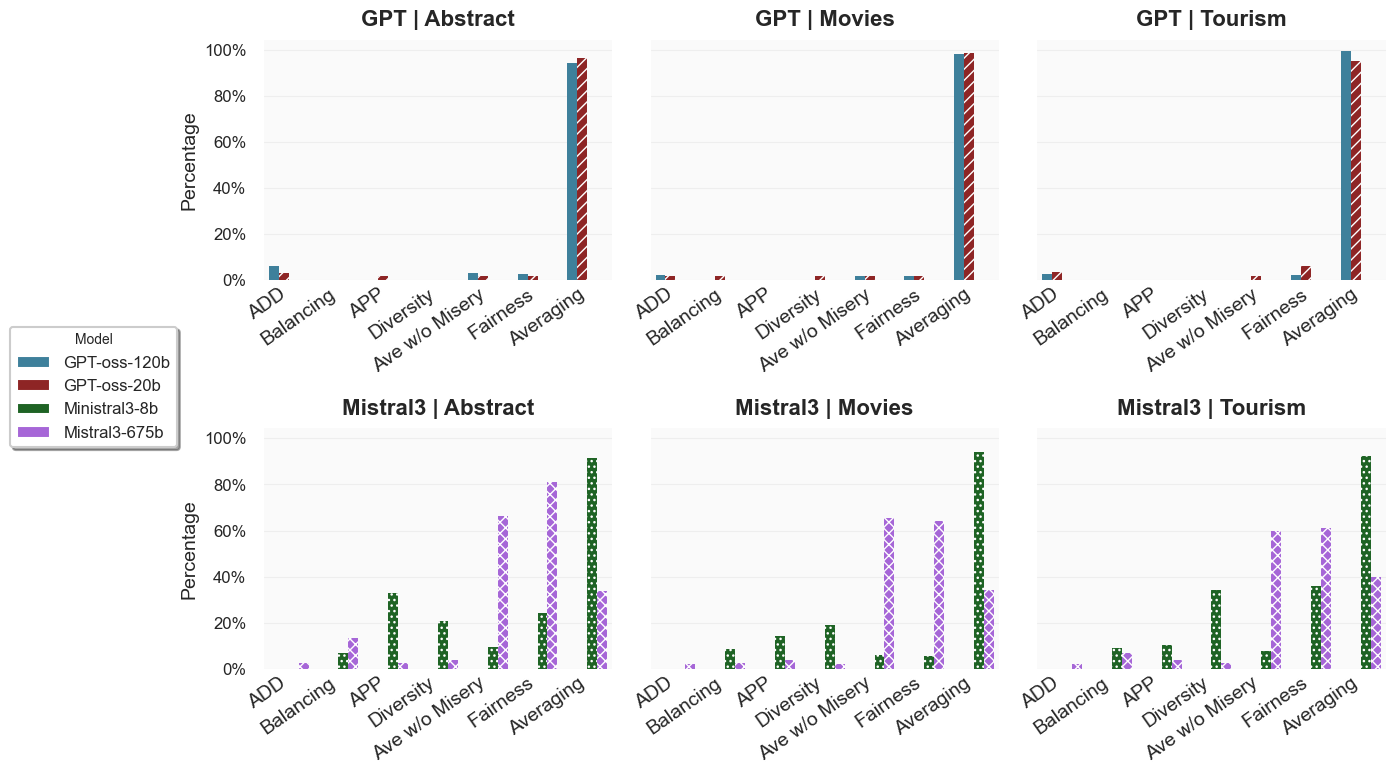

In [140]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from itertools import product

def model_family(llm: str) -> str:
    llm = llm.lower()
    if "gpt" in llm:
        return "GPT"
    elif "stral" in llm:
        return "Mistral3"
    else:
        return "Other"


label_name_map = {
    "Ave": "Averaging",
    "FAI": "Fairness",
    "AWM": "Ave w/o Misery",
    "Div": "Diversity",
    "APP": "APP",
    "Div": "Diversity",
    "BAL": "Balancing",
    "Sim": "Similarity",
    }

model_name_map = {
    "gpt-oss:120b-cloud": "GPT-oss-120b",
    "gpt-oss:20b-cloud": "GPT-oss-20b",
    "ministral-3:8b-cloud": "Ministral3-8b",
    "mistral-large-3:675b-cloud": "Mistral3-675b",
    }


domain_name_map = {
    "anon": 'Abstract',
    "movies": 'Movies',
    'tourist': 'Tourism'
}
df = (
    label_counts[['llm', 'label', 'percentage', 'domain']]
    .groupby(['llm', 'label', 'domain'], as_index=False)
    .mean()
)

df["family"] = df["llm"].apply(model_family)

label_max = df.groupby("label")["percentage"].max()
keep_labels = label_max[label_max >= 0.05].index
df = df[df["label"].isin(keep_labels)]

all_families = df['family'].unique()
all_labels = keep_labels
all_domains = df['domain'].unique()

family_llm_map = df.groupby('family')['llm'].unique().to_dict()

complete_dfs = []
for family in all_families:
    family_llms = family_llm_map[family]
    complete_dfs.append(pd.DataFrame(
        list(product([family], family_llms, all_labels, all_domains)),
        columns=['family', 'llm', 'label', 'domain']
    ))

complete_index = pd.concat(complete_dfs, ignore_index=True)

df = complete_index.merge(
    df,
    on=['family', 'llm', 'label', 'domain'],
    how='left'
)
df['percentage'] = df['percentage'].fillna(0)


df["label_full"] = df["label"].map(label_name_map).fillna(df["label"])
df["llm_ren"] = df["llm"].map(model_name_map).fillna(df["llm"])
df["domain_ren"] = df["domain"].map(domain_name_map).fillna(df["domain"])

label_order = (
    df[df['percentage'] > 0]
    .groupby("label_full")["percentage"]
    .mean()
    .sort_values()
    .index
)


colors = ['#2E86AB', "#A01313", "#126F1B", "#A953EA", '#6A994E', '#BC4B51']
patterns = ['', '///', '...', 'xxx', '\\\\\\', '|||']

sns.set_theme(
    style="whitegrid",
    context="talk",
    font_scale=0.85
)


g = sns.catplot(
    data=df,
    kind="bar",
    x="label_full",
    y="percentage",
    hue="llm_ren",
    col="domain_ren",
    row="family",
    order=label_order,
    height=4,
    aspect=1,
    palette=colors,
    dodge=True,
    errorbar=None,
    sharey=True,sharex=False   
)


for ax in g.axes.flat:
    for i, container in enumerate(ax.containers):
        for bar in container:
            bar.set_hatch(patterns[i % len(patterns)])
            bar.set_edgecolor('white')
            bar.set_linewidth(0.01)

    ax.grid(axis="y", alpha=0.25, linestyle='-', linewidth=0.8)
    ax.set_axisbelow(True)
    ax.set_ylim(bottom=0)
    ax.set_facecolor('#FAFAFA')
    sns.despine(ax=ax, left=True, bottom=True)

    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda y, _: f"{int(y * 100)}%")
    )

    ax.tick_params(axis='x', labelbottom=True)

    ax.tick_params(axis='y', labelsize=12)
    ax.tick_params(axis='x', labelsize=14, length=0)

    plt.setp(
        ax.get_xticklabels(),
        rotation=35,
        ha="right",
        visible=True
    )



g.set_titles(
    col_template="{col_name}",
    row_template="{row_name}",
    size=16,
    weight='bold',
    pad=10
)

g.set_axis_labels("",
    "Percentage",
    fontsize=14
)


handles, labels = g.axes.flat[0].get_legend_handles_labels()

new_handles = []
for i, label in enumerate(labels):
    new_handles.append(
        mpatches.Patch(
            facecolor=colors[i % len(colors)],
            edgecolor='white',
            hatch=patterns[i % len(patterns)],
            linewidth=1.2,
            label=label
        )
    )

g._legend.remove()
g.fig.legend(
    handles=new_handles,
    labels=labels,
    title="Model",
    loc='center right',
    bbox_to_anchor=(0.02, 0.5),
    frameon=True,
    fancybox=True,
    shadow=True,
    title_fontsize=10,
    fontsize=12
)


plt.tight_layout()
plt.subplots_adjust(right=0.88)
plt.savefig('domains-expl.png', dpi=750, bbox_inches='tight')
plt.show()


/var/folders/d4/ddh81b1j0r94c7qm3t38mqcc0000gn/T/ipykernel_37181/442329066.py:66: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  g = sns.catplot(


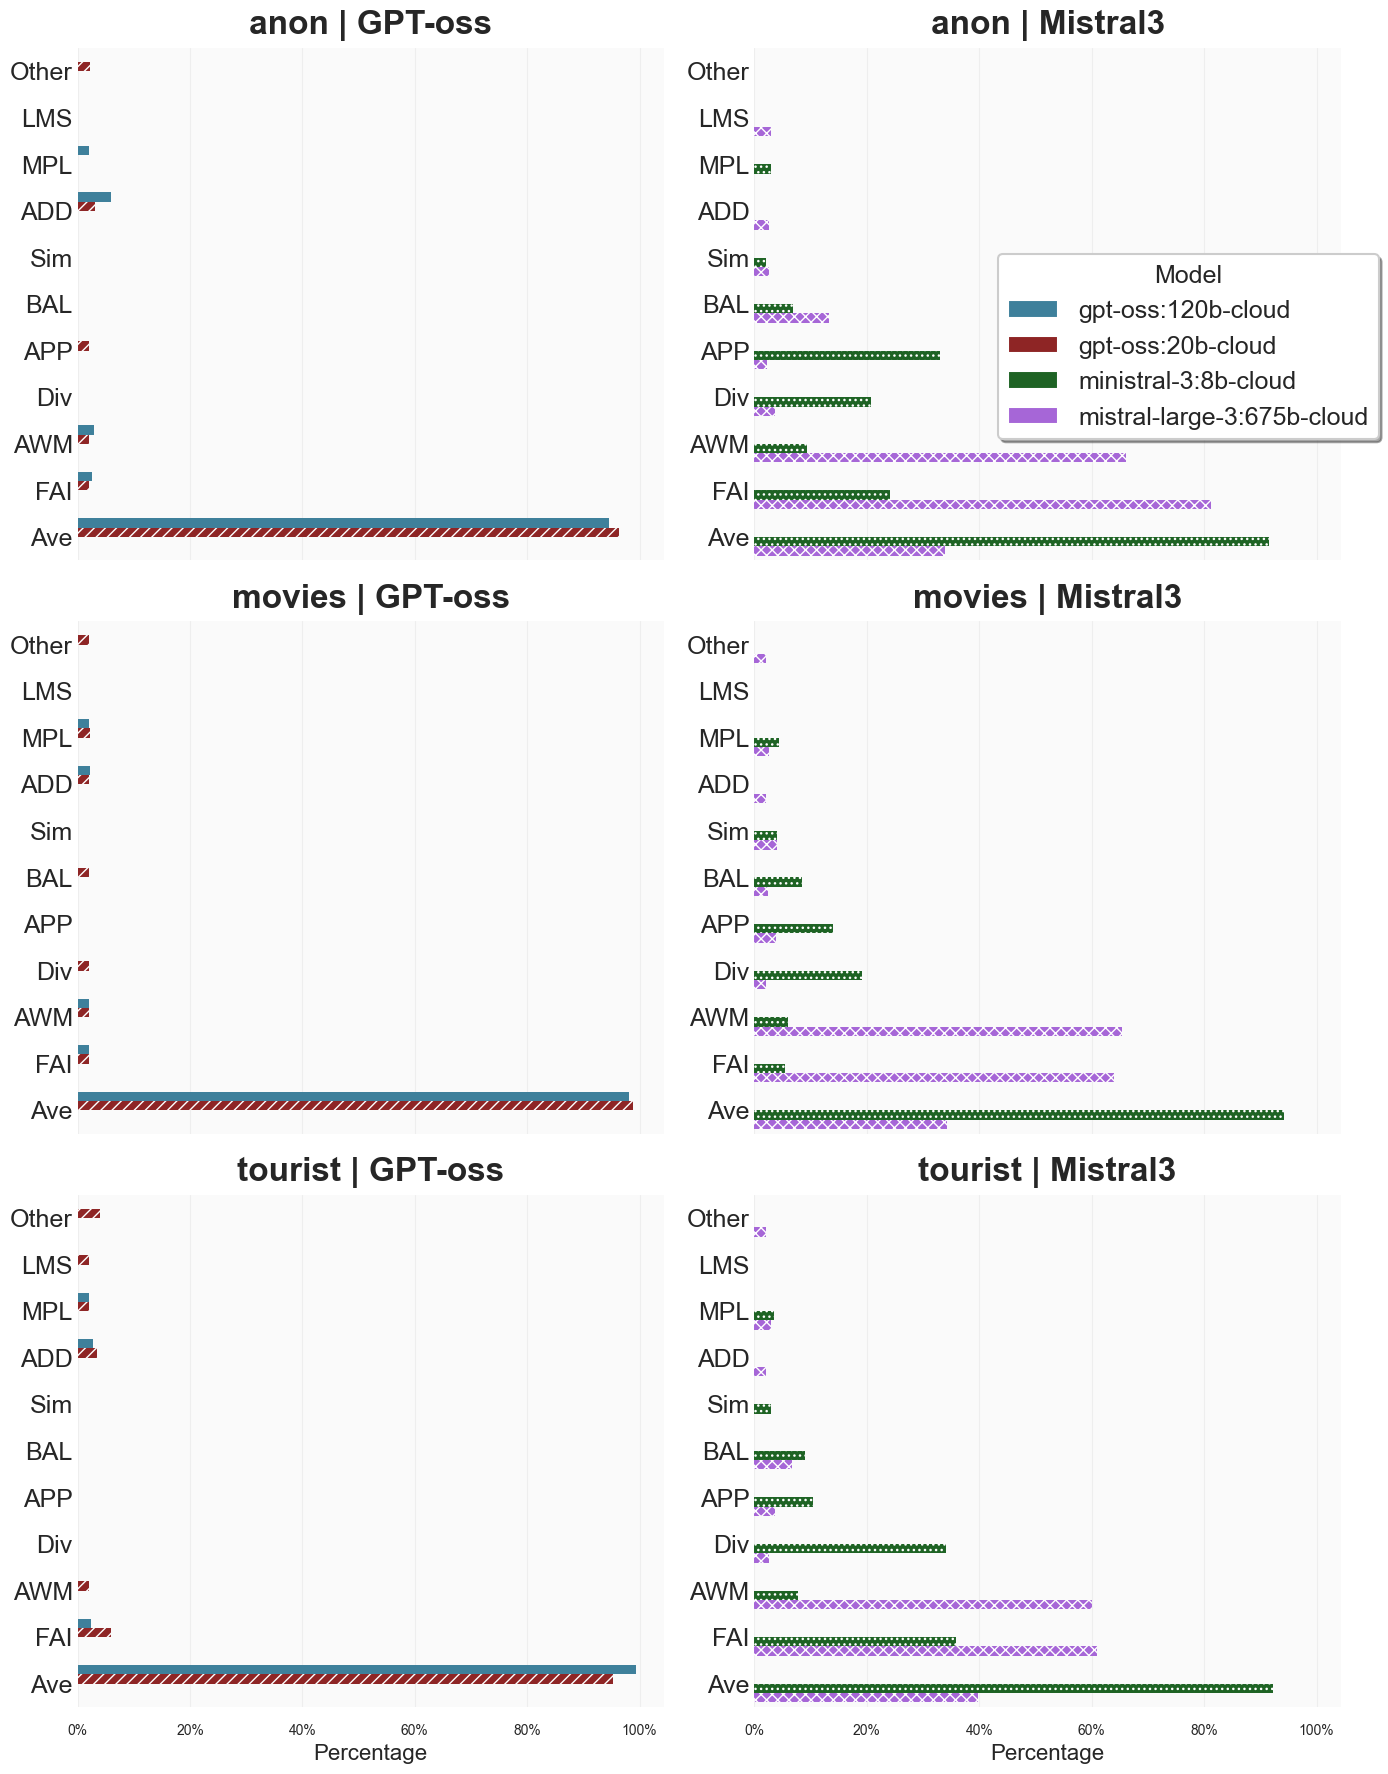

In [ ]:
# OLD GRAPH DOMAIN

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def model_family(llm: str) -> str:
    llm = llm.lower()
    if "gpt" in llm:
        return "GPT-oss"
    elif "stral" in llm:
        return "Mistral3"
    else:
        return "Other"

df = (
    label_counts[['llm', 'label', 'percentage', 'domain']]
    .groupby(['llm', 'label', 'domain'], as_index=False)
    .mean()
)

df["family"] = df["llm"].apply(model_family)

label_max = df.groupby("label")["percentage"].max()
keep_labels = label_max[label_max >= 0.03].index

df = df[df["label"].isin(keep_labels)]

all_families = df['family'].unique()
all_labels = keep_labels
all_configs = df['domain'].unique()

family_llm_map = df.groupby('family')['llm'].unique().to_dict()

complete_dfs = []
for family in all_families:
    family_llms = family_llm_map[family]
    from itertools import product
    family_combinations = pd.DataFrame(
        list(product([family], family_llms, all_labels, all_configs)),
        columns=['family', 'llm', 'label', 'domain']
    )
    complete_dfs.append(family_combinations)

complete_index = pd.concat(complete_dfs, ignore_index=True)

df = complete_index.merge(df, on=['family', 'llm', 'label', 'domain'], how='left')
df['percentage'] = df['percentage'].fillna(0)

label_order = (
    df[df['percentage'] > 0].groupby("label")["percentage"]
    .mean()
    .sort_values()
    .index
)
config_order = sorted(df['domain'].unique())

colors = ['#2E86AB', "#A01313", "#126F1B", "#A953EA", '#6A994E', '#BC4B51']

patterns = ['', '///', '...', 'xxx', '\\\\\\', '|||']

sns.set_theme(
    style="whitegrid",
    context="talk",
    font_scale=0.85
)

g = sns.catplot(
    data=df,
    kind="bar",
    x="percentage",
    y="label",
    hue="llm",         
    col="family",
    row='domain',      
    order=label_order,
    height=6,  
    aspect=0.9,
    palette=colors,
    dodge=True,
    errorbar=None,
    sharey=True
)

for ax in g.axes.flat:
    for i, container in enumerate(ax.containers):
        for bar in container:
            bar.set_hatch(patterns[i % len(patterns)])
            bar.set_edgecolor('white')
            bar.set_linewidth(.01)
    
    ax.grid(axis="x", alpha=0.25, linestyle='-', linewidth=0.8)
    ax.set_axisbelow(True)
    ax.set_xlim(left=0)
    
    sns.despine(ax=ax, left=True, bottom=True)
    
    ax.set_facecolor('#FAFAFA')
    
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x*100)}%'))
    
    ax.tick_params(axis='y', labelsize=18, length=0, labelleft=True)
    ax.tick_params(axis='x', labelsize=10)

g.set_titles(col_template="{col_name}", row_template="{row_name}", size=24, weight='bold', pad=10)

g.set_axis_labels("Percentage", "", fontsize=16)

handles, labels = g.axes.flat[0].get_legend_handles_labels()
new_handles = []
for i, (handle, label) in enumerate(zip(handles, labels)):
    new_handle = mpatches.Patch(
        facecolor=colors[i % len(colors)],
        edgecolor='white',
        hatch=patterns[i % len(patterns)],
        linewidth=1.2,
        label=label
    )
    new_handles.append(new_handle)

g._legend.remove()
g.fig.legend(
    handles=new_handles,
    labels=labels,
    title="Model",
    loc='center right',
    bbox_to_anchor=(1.02, 0.8),
    frameon=True,
    fancybox=True,
    shadow=True,
    title_fontsize=18,
    fontsize=18
)

plt.tight_layout()
plt.subplots_adjust()

/var/folders/d4/ddh81b1j0r94c7qm3t38mqcc0000gn/T/ipykernel_44951/4097425312.py:94: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  g = sns.catplot(


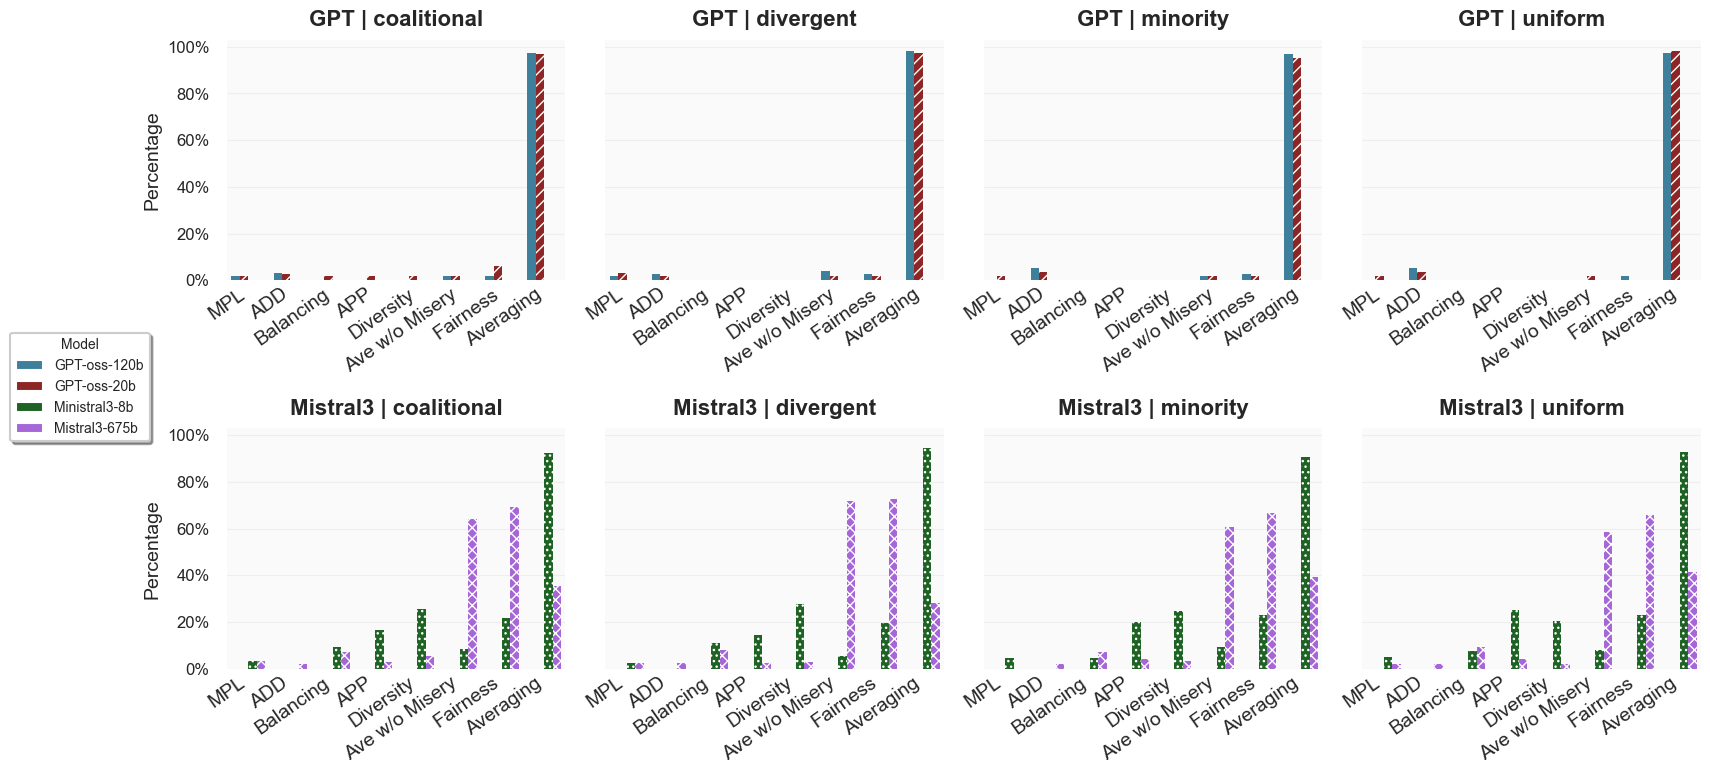

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from itertools import product

def model_family(llm: str) -> str:
    llm = llm.lower()
    if "gpt" in llm:
        return "GPT"
    elif "stral" in llm:
        return "Mistral3"
    else:
        return "Other"


label_name_map = {
    "Ave": "Averaging",
    "FAI": "Fairness",
    "AWM": "Ave w/o Misery",
    "Div": "Diversity",
    "APP": "APP",
    "Div": "Diversity",
    "BAL": "Balancing",
    "Sim": "Similarity",
    }

model_name_map = {
    "gpt-oss:120b-cloud": "GPT-oss-120b",
    "gpt-oss:20b-cloud": "GPT-oss-20b",
    "ministral-3:8b-cloud": "Ministral3-8b",
    "mistral-large-3:675b-cloud": "Mistral3-675b",


}

df = (
    label_counts[['llm', 'label', 'percentage', 'configuration']]
    .groupby(['llm', 'label', 'configuration'], as_index=False)
    .mean()
)

df["family"] = df["llm"].apply(model_family)

label_max = df.groupby("label")["percentage"].max()
keep_labels = label_max[label_max >= 0.05].index
df = df[df["label"].isin(keep_labels)]

all_families = df['family'].unique()
all_labels = keep_labels
all_domains = df['configuration'].unique()

family_llm_map = df.groupby('family')['llm'].unique().to_dict()

complete_dfs = []
for family in all_families:
    family_llms = family_llm_map[family]
    complete_dfs.append(pd.DataFrame(
        list(product([family], family_llms, all_labels, all_domains)),
        columns=['family', 'llm', 'label', 'configuration']
    ))

complete_index = pd.concat(complete_dfs, ignore_index=True)

df = complete_index.merge(
    df,
    on=['family', 'llm', 'label', 'configuration'],
    how='left'
)
df['percentage'] = df['percentage'].fillna(0)


df["label_full"] = df["label"].map(label_name_map).fillna(df["label"])
df["llm_ren"] = df["llm"].map(model_name_map).fillna(df["llm"])

label_order = (
    df[df['percentage'] > 0]
    .groupby("label_full")["percentage"]
    .mean()
    .sort_values()
    .index
)


colors = ['#2E86AB', "#A01313", "#126F1B", "#A953EA", '#6A994E', '#BC4B51']
patterns = ['', '///', '...', 'xxx', '\\\\\\', '|||']

sns.set_theme(
    style="whitegrid",
    context="talk",
    font_scale=0.85
)


g = sns.catplot(
    data=df,
    kind="bar",
    x="label_full",
    y="percentage",
    hue="llm_ren",
    col="configuration",
    row="family",
    order=label_order,
    height=4,
    aspect=1,
    palette=colors,
    dodge=True,
    errorbar=None,
    sharey=True,sharex=False   
)


for ax in g.axes.flat:
    for i, container in enumerate(ax.containers):
        for bar in container:
            bar.set_hatch(patterns[i % len(patterns)])
            bar.set_edgecolor('white')
            bar.set_linewidth(0.01)

    ax.grid(axis="y", alpha=0.25, linestyle='-', linewidth=0.8)
    ax.set_axisbelow(True)
    ax.set_ylim(bottom=0)
    ax.set_facecolor('#FAFAFA')
    sns.despine(ax=ax, left=True, bottom=True)

    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda y, _: f"{int(y * 100)}%")
    )

    ax.tick_params(axis='x', labelbottom=True)

    ax.tick_params(axis='y', labelsize=12)
    ax.tick_params(axis='x', labelsize=14, length=0)

    plt.setp(
        ax.get_xticklabels(),
        rotation=35,
        ha="right",
        visible=True
    )



g.set_titles(
    col_template="{col_name}",
    row_template="{row_name}",
    size=16,
    weight='bold',
    pad=10
)

g.set_axis_labels(
    "",
    "Percentage",
    fontsize=14
)


handles, labels = g.axes.flat[0].get_legend_handles_labels()

new_handles = []
for i, label in enumerate(labels):
    new_handles.append(
        mpatches.Patch(
            facecolor=colors[i % len(colors)],
            edgecolor='white',
            hatch=patterns[i % len(patterns)],
            linewidth=1.2,
            label=label
        )
    )

g._legend.remove()
g.fig.legend(
    handles=new_handles,
    labels=labels,
    title="Model",
    loc='center right',
    bbox_to_anchor=(0.02, 0.5),
    frameon=True,
    fancybox=True,
    shadow=True,
    title_fontsize=10,
    fontsize=10
)


plt.tight_layout()
plt.subplots_adjust(right=0.88)
plt.savefig('configurations-expl.png', dpi=750, bbox_inches='tight')

plt.show()


/var/folders/d4/ddh81b1j0r94c7qm3t38mqcc0000gn/T/ipykernel_44951/3435520987.py:66: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  g = sns.catplot(


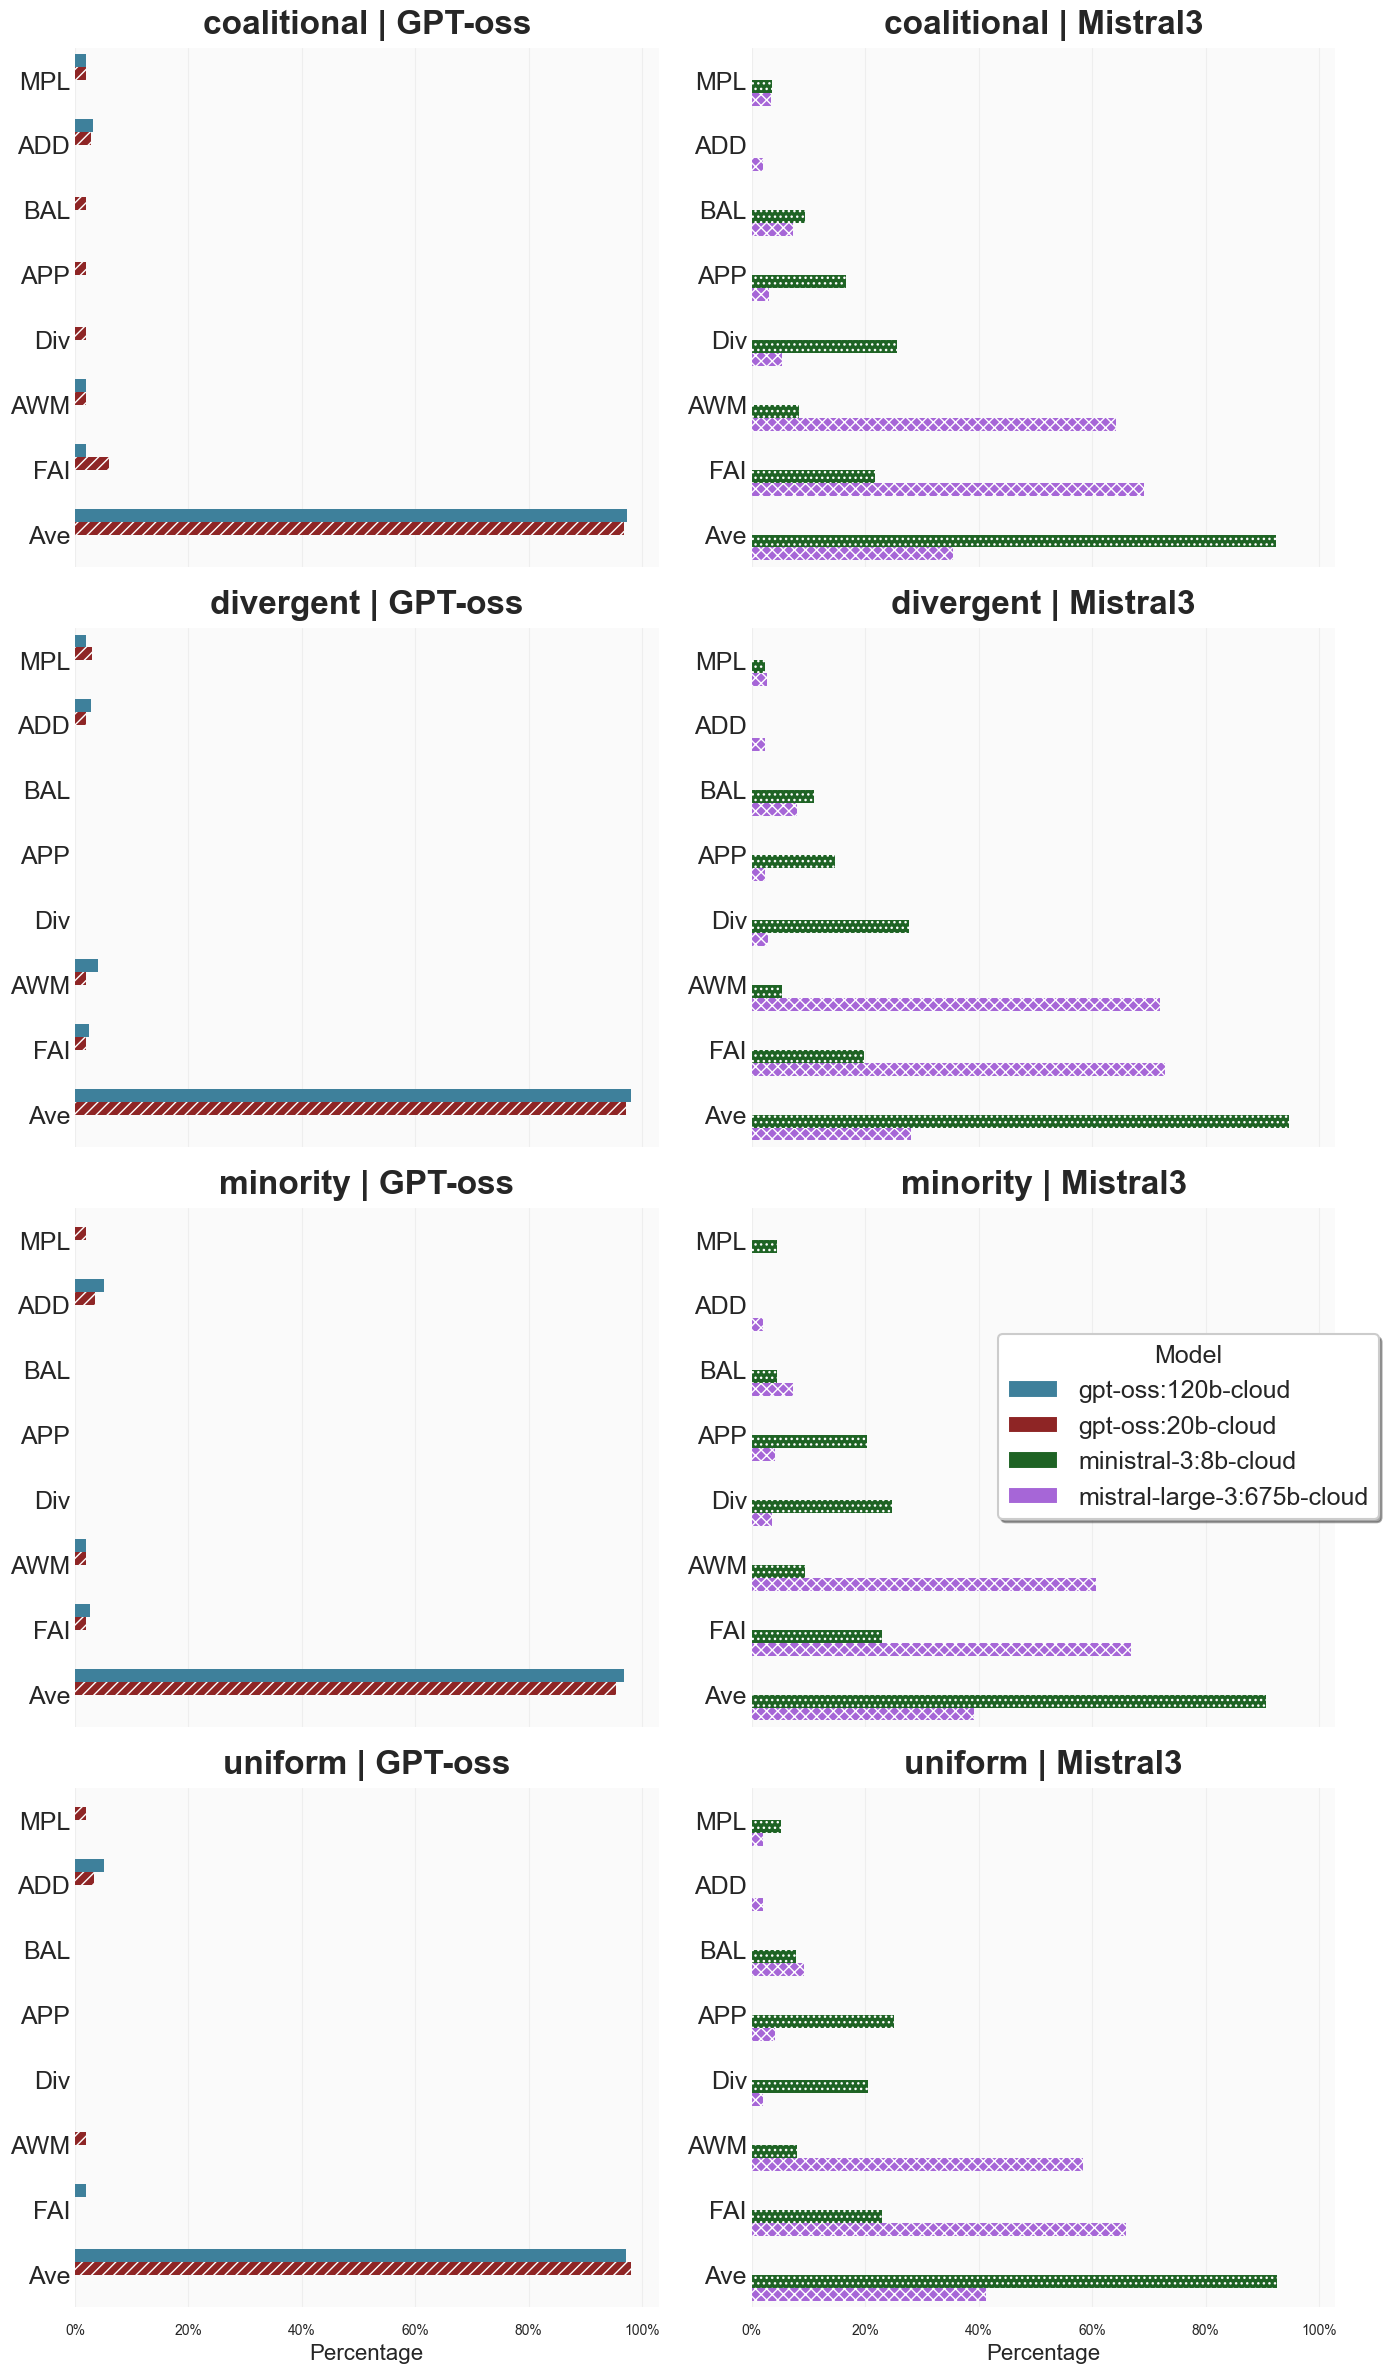

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def model_family(llm: str) -> str:
    llm = llm.lower()
    if "gpt" in llm:
        return "GPT-oss"
    elif "stral" in llm:
        return "Mistral3"
    else:
        return "Other"

df = (
    label_counts[['llm', 'label', 'percentage', 'configuration']]
    .groupby(['llm', 'label', 'configuration'], as_index=False)
    .mean()
)

df["family"] = df["llm"].apply(model_family)

label_max = df.groupby("label")["percentage"].max()
keep_labels = label_max[label_max >= 0.05].index

df = df[df["label"].isin(keep_labels)]

all_families = df['family'].unique()
all_labels = keep_labels
all_configs = df['configuration'].unique()

family_llm_map = df.groupby('family')['llm'].unique().to_dict()

complete_dfs = []
for family in all_families:
    family_llms = family_llm_map[family]
    from itertools import product
    family_combinations = pd.DataFrame(
        list(product([family], family_llms, all_labels, all_configs)),
        columns=['family', 'llm', 'label', 'configuration']
    )
    complete_dfs.append(family_combinations)

complete_index = pd.concat(complete_dfs, ignore_index=True)

df = complete_index.merge(df, on=['family', 'llm', 'label', 'configuration'], how='left')
df['percentage'] = df['percentage'].fillna(0)

label_order = (
    df[df['percentage'] > 0].groupby("label")["percentage"]
    .mean()
    .sort_values()
    .index
)
config_order = sorted(df['configuration'].unique())

colors = ['#2E86AB', "#A01313", "#126F1B", "#A953EA", '#6A994E', '#BC4B51']

patterns = ['', '///', '...', 'xxx', '\\\\\\', '|||']

sns.set_theme(
    style="whitegrid",
    context="talk",
    font_scale=0.85
)

g = sns.catplot(
    data=df,
    kind="bar",
    x="percentage",
    y="label",
    hue="llm",         
    col="family",
    row='configuration',      
    order=label_order,
    height=6,  
    aspect=0.9,
    palette=colors,
    dodge=True,
    errorbar=None,
    sharey=True
)

for ax in g.axes.flat:
    for i, container in enumerate(ax.containers):
        for bar in container:
            bar.set_hatch(patterns[i % len(patterns)])
            bar.set_edgecolor('white')
            bar.set_linewidth(0.01)
    
    ax.grid(axis="x", alpha=0.25, linestyle='-', linewidth=0.8)
    ax.set_axisbelow(True)
    ax.set_xlim(left=0)
    
    sns.despine(ax=ax, left=True, bottom=True)
    
    ax.set_facecolor('#FAFAFA')
    
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x*100)}%'))
    
    ax.tick_params(axis='y', labelsize=18, length=0, labelleft=True)
    ax.tick_params(axis='x', labelsize=10)

g.set_titles(col_template="{col_name}", row_template="{row_name}", size=24, weight='bold', pad=10)

g.set_axis_labels("Percentage", "", fontsize=16)

handles, labels = g.axes.flat[0].get_legend_handles_labels()
new_handles = []
for i, (handle, label) in enumerate(zip(handles, labels)):
    new_handle = mpatches.Patch(
        facecolor=colors[i % len(colors)],
        edgecolor='white',
        hatch=patterns[i % len(patterns)],
        linewidth=1.2,
        label=label
    )
    new_handles.append(new_handle)

g._legend.remove()
g.fig.legend(
    handles=new_handles,
    labels=labels,
    title="Model",
    loc='center right',
    bbox_to_anchor=(1.02, 0.4),
    frameon=True,
    fancybox=True,
    shadow=True,
    title_fontsize=18,
    fontsize=18
)

plt.tight_layout()
plt.subplots_adjust()

/var/folders/d4/ddh81b1j0r94c7qm3t38mqcc0000gn/T/ipykernel_37181/2617162878.py:66: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  g = sns.catplot(


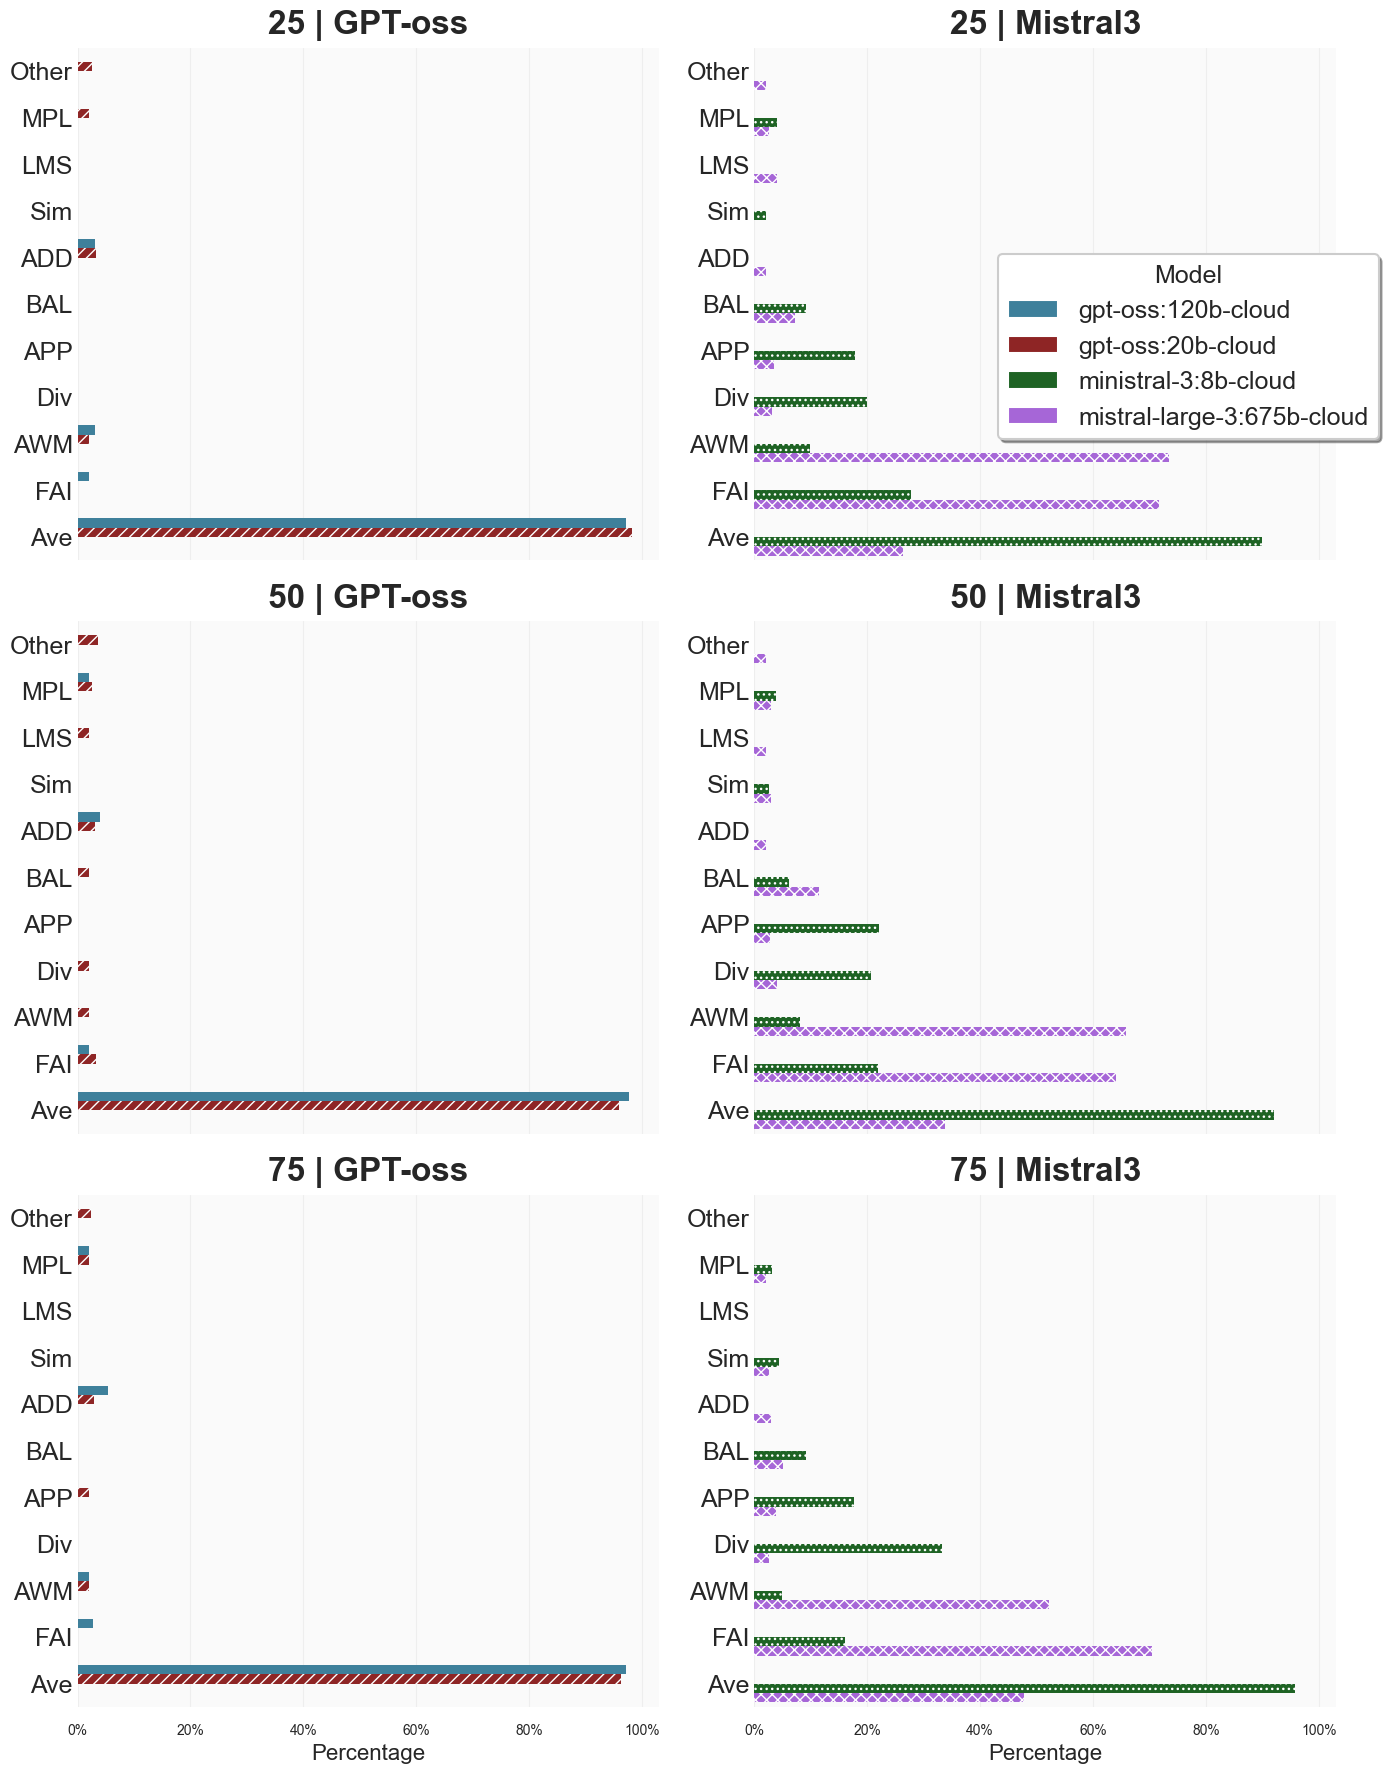

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def model_family(llm: str) -> str:
    llm = llm.lower()
    if "gpt" in llm:
        return "GPT-oss"
    elif "stral" in llm:
        return "Mistral3"
    else:
        return "Other"

df = (
    label_counts[['llm', 'label', 'percentage', 'num_items']]
    .groupby(['llm', 'label', 'num_items'], as_index=False)
    .mean()
)

df["family"] = df["llm"].apply(model_family)

label_max = df.groupby("label")["percentage"].max()
keep_labels = label_max[label_max >= 0.03].index

df = df[df["label"].isin(keep_labels)]

all_families = df['family'].unique()
all_labels = keep_labels
all_configs = df['num_items'].unique()

family_llm_map = df.groupby('family')['llm'].unique().to_dict()

complete_dfs = []
for family in all_families:
    family_llms = family_llm_map[family]
    from itertools import product
    family_combinations = pd.DataFrame(
        list(product([family], family_llms, all_labels, all_configs)),
        columns=['family', 'llm', 'label', 'num_items']
    )
    complete_dfs.append(family_combinations)

complete_index = pd.concat(complete_dfs, ignore_index=True)

df = complete_index.merge(df, on=['family', 'llm', 'label', 'num_items'], how='left')
df['percentage'] = df['percentage'].fillna(0)

label_order = (
    df[df['percentage'] > 0].groupby("label")["percentage"]
    .mean()
    .sort_values()
    .index
)
config_order = sorted(df['num_items'].unique())

colors = ['#2E86AB', "#A01313", "#126F1B", "#A953EA", '#6A994E', '#BC4B51']

patterns = ['', '///', '...', 'xxx', '\\\\\\', '|||']

sns.set_theme(
    style="whitegrid",
    context="talk",
    font_scale=0.85
)

g = sns.catplot(
    data=df,
    kind="bar",
    x="percentage",
    y="label",
    hue="llm",         
    col="family",
    row='num_items',      
    order=label_order,
    height=6,  
    aspect=0.9,
    palette=colors,
    dodge=True,
    errorbar=None,
    sharey=True
)

for ax in g.axes.flat:
    for i, container in enumerate(ax.containers):
        for bar in container:
            bar.set_hatch(patterns[i % len(patterns)])
            bar.set_edgecolor('white')
            bar.set_linewidth(0.01)
    
    ax.grid(axis="x", alpha=0.25, linestyle='-', linewidth=0.8)
    ax.set_axisbelow(True)
    ax.set_xlim(left=0)
    
    sns.despine(ax=ax, left=True, bottom=True)
    
    ax.set_facecolor('#FAFAFA')
    
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x*100)}%'))
    
    ax.tick_params(axis='y', labelsize=18, length=0, labelleft=True)
    ax.tick_params(axis='x', labelsize=10)

g.set_titles(col_template="{col_name}", row_template="{row_name}", size=24, weight='bold', pad=10)

g.set_axis_labels("Percentage", "", fontsize=16)

handles, labels = g.axes.flat[0].get_legend_handles_labels()
new_handles = []
for i, (handle, label) in enumerate(zip(handles, labels)):
    new_handle = mpatches.Patch(
        facecolor=colors[i % len(colors)],
        edgecolor='white',
        hatch=patterns[i % len(patterns)],
        linewidth=1.2,
        label=label
    )
    new_handles.append(new_handle)

g._legend.remove()
g.fig.legend(
    handles=new_handles,
    labels=labels,
    title="Model",
    loc='center right',
    bbox_to_anchor=(1.02, 0.8),
    frameon=True,
    fancybox=True,
    shadow=True,
    title_fontsize=18,
    fontsize=18
)

plt.tight_layout()
plt.subplots_adjust()

In [96]:
ndcg_cols = ["ADD_ndcg10", "APP_ndcg10", "LMS_ndcg10", "MPL_ndcg10", "MAJ_ndcg10", 'BORDA_ndcg10', 'AWM_ndcg10']
df_long = (
    df_results
    .melt(
        id_vars=[c for c in df_results.columns if c not in ndcg_cols],
        value_vars=ndcg_cols,
        var_name="strategy",
        value_name="ndcg10"
    )
)
df_long["strategy"] = df_long["strategy"].str.replace("_ndcg10", "", regex=False)


In [ ]:
import statsmodels.formula.api as smf

model = smf.mixedlm(
    formula="ndcg10 ~ configuration + C(num_items) + C(strategy) + C(llm) * C(strategy) + C(domain) * C(llm) * C(strategy)",
    data=df_long,
    groups=df_long["groupID"]  
)

result = model.fit()
print(result.summary())



                                          Mixed Linear Model Regression Results
Model:                                  MixedLM                       Dependent Variable:                       ndcg10    
No. Observations:                       50400                         Method:                                   REML      
No. Groups:                             600                           Scale:                                    0.0157    
Min. group size:                        84                            Log-Likelihood:                           32085.4722
Max. group size:                        84                            Converged:                                Yes       
Mean group size:                        84.0                                                                              
--------------------------------------------------------------------------------------------------------------------------
                                                           

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [139]:
wald_results = result.wald_test_terms()

df_wald = wald_results.summary_frame()
print(df_wald)

hypothesis = "C(llm)[T.mistral-large-3:675b-cloud] = C(llm)[T.ministral-3:8b-cloud]"
wald_result = result.wald_test(hypothesis, scalar=True)
print(wald_result)

                                                    chi2  \
Intercept                         [[16777.700599005846]]   
configuration                     [[0.6477577112500903]]   
C(llm)                            [[1377.1759232309541]]   
C(strategy)                        [[6800.490241904714]]   
C(num_items)                      [[1515.3961269844217]]   
C(domain)                          [[2.667168249985096]]   
configuration:C(llm)               [[266.8981222250222]]   
configuration:C(strategy)          [[411.5595161979685]]   
C(llm):C(strategy)                [[2433.6655401325843]]   
C(domain):C(llm)                  [[161.08517208353442]]   
C(domain):C(strategy)              [[5.462934878589692]]   
configuration:C(llm):C(strategy)   [[408.2549986190339]]   
C(domain):C(llm):C(strategy)      [[176.30024895623052]]   

                                                   P>chi2  df constraint  
Intercept                                             0.0              1  
configura

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
